# 📊 Exploratory Data Analysis - Karachi Air Quality

## Understanding OpenMeteo Historical Data Through Visualization

### 💭 My Analytical Journey

Before building any prediction models, I need to understand **what the data is telling me**. This notebook captures my thought process as I explore the patterns, trends, and relationships in Karachi's air quality data from OpenMeteo.

### 🎯 Key Questions Driving My Analysis:
1. **Data Quality**: Is the data complete and reliable?
2. **Temporal Patterns**: When is air quality worst? Best?
3. **Pollutant Impact**: Which pollutants drive AQI the most?
4. **Feature Relationships**: How do features correlate?
5. **Modeling Insights**: What will help my ML models?

### 📖 What I'm Looking For:
- **Trends**: Long-term patterns over months
- **Seasonality**: Daily and weekly cycles
- **Anomalies**: Unusual pollution events
- **Correlations**: What predicts AQI best?

## 1️⃣ Setup & Initial Data Load

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import hopsworks
import os

from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')
from ydata_profiling import ProfileReport

# Styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

load_dotenv()
print("All libraries loaded!")

c:\Users\Hp-21\Downloads\AQI_Predictor\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-02-16 15:29:05,233 INFO: Pandas backend loaded 2.1.4
2026-02-16 15:29:05,250 INFO: Numpy backend loaded 1.26.4
2026-02-16 15:29:05,268 INFO: Pyspark backend loaded 4.1.1
2026-02-16 15:29:05,271 INFO: Python backend loaded
All libraries loaded!


### 💭 First Thought: Getting the Data

I'm loading data from Hopsworks Feature Store, where OpenMeteo historical data is stored. My immediate questions:
- How many hours of data do we have?
- Does it cover enough time for seasonal analysis?
- Is it recent enough to be relevant?

In [2]:
# Connect to Hopsworks and load data
print("Connecting to Hopsworks...")
project = hopsworks.login(
    api_key_value=os.getenv("HOPSWORKS_API_KEY"),
    project=os.getenv("HOPSWORKS_PROJECT_NAME")
)

fs = project.get_feature_store()
fg = fs.get_feature_group("karachi_air_quality", version=6)

print("\nLoading historical data from OpenMeteo API...")
df = fg.read()

# Process timestamps
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

# Extract temporal features
df['hour'] = df['timestamp'].dt.hour
df['weekday'] = df['timestamp'].dt.weekday
df['month'] = df['timestamp'].dt.month
df['day'] = df['timestamp'].dt.day
df['year'] = df['timestamp'].dt.year

# Initial overview
print(f"\n{'='*60}")
print(f"📊 DATASET OVERVIEW")
print(f"{'='*60}")
print(f"Total rows: {len(df):,}")
print(f"Total columns: {df.shape[1]}")
print(f"Time period: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Duration: {(df['timestamp'].max() - df['timestamp'].min()).days} days")
print(f"{'='*60}\n")

Connecting to Hopsworks...
2026-02-16 15:29:12,097 INFO: Initializing external client
2026-02-16 15:29:12,098 INFO: Base URL: https://c.app.hopsworks.ai:443
2026-02-16 15:29:15,323 INFO: Python Engine initialized.

Logged in to project, explore it here https://c.app.hopsworks.ai:443/p/1334422

Loading historical data from OpenMeteo API...
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (6.36s) 

📊 DATASET OVERVIEW
Total rows: 8,784
Total columns: 80
Time period: 2025-02-15 00:00:00+00:00 to 2026-02-15 23:00:00+00:00
Duration: 365 days



### 💭 Initial:
- Capture seasonal patterns (winter smog vs summer clarity)
- Understand daily cycles (morning rush hour, evening peaks)
- Build reliable time series models

In [5]:
# First look at the data
print("First 10 rows:\n")
df.head(10)

First 10 rows:



,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,timestamp,event_id,aqi,hour,day,month,weekday,dayofyear,is_weekend,pm2_5_lag1,pm2_5_lag3,pm2_5_lag6,pm2_5_lag24,pm10_lag1,pm10_lag3,pm10_lag6,pm10_lag24,carbon_monoxide_lag1,carbon_monoxide_lag3,carbon_monoxide_lag6,carbon_monoxide_lag24,nitrogen_dioxide_lag1,nitrogen_dioxide_lag3,nitrogen_dioxide_lag6,nitrogen_dioxide_lag24,sulphur_dioxide_lag1,sulphur_dioxide_lag3,sulphur_dioxide_lag6,sulphur_dioxide_lag24,ozone_lag1,ozone_lag3,ozone_lag6,ozone_lag24,aqi_lag1,aqi_lag3,aqi_lag6,aqi_lag24,pm2_5_roll6,pm2_5_roll12,pm2_5_roll24,pm10_roll6,pm10_roll12,pm10_roll24,carbon_monoxide_roll6,carbon_monoxide_roll12,carbon_monoxide_roll24,nitrogen_dioxide_roll6,nitrogen_dioxide_roll12,nitrogen_dioxide_roll24,sulphur_dioxide_roll6,sulphur_dioxide_roll12,sulphur_dioxide_roll24,ozone_roll6,ozone_roll12,ozone_roll24,aqi_roll6,aqi_roll12,aqi_roll24,pm2_5_diff1,pm2_5_diff24,pm10_diff1,pm10_diff24,carbon_monoxide_diff1,carbon_monoxide_diff24,nitrogen_dioxide_diff1,nitrogen_dioxide_diff24,sulphur_dioxide_diff1,sulphur_dioxide_diff24,ozone_diff1,ozone_diff24,aqi_diff1,aqi_diff24,target_aqi_t24,year
0,21.5,43.4,180.0,5.3,5.5,81.0,2025-02-15 00:00:00+00:00,1739577600,70.768240,0,15,2,5,46,1,20.5,20.3,24.9,20.5,42.0,40.7,44.7,45.3,153.0,181.0,337.0,227.0,4.9,9.2,24.6,9.4,5.2,5.5,8.9,7.5,82.0,79.0,63.0,68.0,68.665236,68.244635,77.918455,68.665236,21.066667,23.975000,25.625000,41.800000,44.608333,54.133333,191.833333,367.500000,411.500000,9.733333,20.550000,20.025000,5.900000,8.325000,11.779167,77.833333,69.416667,76.791667,69.856938,75.973176,79.443133,1.0,1.0,1.4,-1.9,27.0,-47.0,0.4,-4.1,0.3,-2.0,-1.0,13.0,2.103004,2.103004,60.253219,2025
1,22.2,43.9,274.0,11.0,6.3,73.0,2025-02-15 01:00:00+00:00,1739581200,72.240343,1,15,2,5,46,1,21.5,20.1,22.9,21.2,43.4,41.4,42.3,52.7,180.0,158.0,265.0,397.0,5.3,6.4,19.1,18.1,5.5,5.1,7.7,8.7,81.0,81.0,69.0,56.0,70.768240,67.824034,73.712446,70.137339,20.950000,23.650000,25.666667,42.066667,44.291667,53.766667,193.333333,347.000000,406.375000,8.383333,19.533333,19.729167,5.666667,7.766667,11.679167,78.500000,68.750000,77.500000,69.611588,75.289700,79.530758,0.7,1.0,0.5,-8.8,94.0,-123.0,5.7,-7.1,0.8,-2.4,-8.0,17.0,1.472103,2.103004,61.725322,2025
2,24.0,45.6,400.0,18.6,7.5,63.0,2025-02-15 02:00:00+00:00,1739584800,76.025751,2,15,2,5,46,1,22.2,20.5,21.1,24.1,43.9,42.0,41.0,59.6,274.0,153.0,214.0,629.0,11.0,4.9,13.5,29.8,6.3,5.2,6.4,10.5,73.0,82.0,75.0,41.0,72.240343,68.665236,69.927039,76.236052,21.433333,23.308333,25.662500,42.833333,44.133333,53.183333,224.333333,327.083333,396.833333,9.233333,18.308333,19.262500,5.850000,7.400000,11.554167,76.500000,68.750000,78.416667,70.628040,74.571173,79.521996,1.8,-0.1,1.7,-14.0,126.0,-229.0,7.6,-11.2,1.2,-3.0,-10.0,22.0,3.785408,-0.210300,66.141631,2025
3,27.6,49.9,475.0,23.3,9.0,59.0,2025-02-15 03:00:00+00:00,1739588400,83.596567,3,15,2,5,46,1,24.0,21.5,20.3,31.7,45.6,43.4,40.7,68.2,400.0,180.0,181.0,762.0,18.6,5.3,9.2,36.5,7.5,5.5,5.5,12.4,63.0,81.0,79.0,35.0,76.025751,70.768240,68.244635,92.218884,22.650000,23.266667,25.491667,44.366667,44.233333,52.420833,273.333333,309.250000,384.875000,11.583333,16.991667,18.712500,6.433333,7.241667,11.412500,73.166667,69.416667,79.416667,73.186695,74.483548,79.162732,3.6,-4.1,4.3,-18.3,75.0,-287.0,4.7,-13.2,1.5,-3.4,-4.0,24.0,7.570815,-8.622318,76.025751,2025
4,29.9,54.8,447.0,22.2,10.8,67.0,2025-02-15 04:00:00+00:00,1739592000,88.433476,4,15,2,5,46,1,27.6,22.2,20.1,32.1,49.9,43.9,41.4,64.7,475.0,274.0,158.0,700.0,23.3,11.0,6.4,33.8,9.0,6.3,5.1,14.4,59.0,73.0,81.0,48.0,83.596567,72.240343,67.824034,93.060086,24.283333,23.458333,25.400000,46.600000,44.725000,52.008333,321.500000,295.583333,374.333333,14.216667,15.750000,18.229167,7.383333,7.291667,11.262500,70.833333,70.750000,80.208333,76.621602,74.886624,78.969957,2.3,-2.2,4.9,-9.9,-28.0,-253.0,-1.1,-11.6,1.8,-3.6,8.0,19.0,4.836910,-4.626609,81.493562,2025
5,30.5,70.5,367.0,18.2,12.9,81.0,2025-02-15 05:00:00+00:00,17395

In [4]:
# Data types and structure
print("Data Structure:\n")
df.info()

Data Structure:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 80 columns):
 #   Column                   Non-Null Count  Dtype                  
---  ------                   --------------  -----                  
 0   pm2_5                    8784 non-null   float64                
 1   pm10                     8784 non-null   float64                
 2   carbon_monoxide          8784 non-null   float64                
 3   nitrogen_dioxide         8784 non-null   float64                
 4   sulphur_dioxide          8784 non-null   float64                
 5   ozone                    8784 non-null   float64                
 6   timestamp                8784 non-null   datetime64[us, Etc/UTC]
 7   event_id                 8784 non-null   object                 
 8   aqi                      8784 non-null   float64                
 9   hour                     8784 non-null   int32                  
 10  day                      8784 n

In [5]:
# Statistical summary
print("Statistical Summary:\n")
print(df.describe().T.to_string())

Statistical Summary:

                          count         mean         std          min          25%          50%          75%          max
pm2_5                    8784.0    29.110155   13.024518     3.800000    20.300000    26.100000    34.600000    96.400000
pm10                     8784.0    55.817407   34.535893     3.900000    34.700000    48.700000    68.000000   385.600000
carbon_monoxide          8784.0   548.711976  457.460426    74.000000   253.000000   374.000000   690.000000  4515.000000
nitrogen_dioxide         8784.0    21.978575   19.807931     0.000000     7.900000    15.100000    29.400000   138.500000
sulphur_dioxide          8784.0    16.278563    8.411917     4.900000    10.700000    14.000000    19.400000    65.400000
ozone                    8784.0    71.485997   40.603256     0.000000    43.000000    63.000000    96.000000   213.000000
aqi                      8784.0    86.801120   26.793299    15.833333    68.244635    80.442060    98.317597   172.118019
ho

## 2️⃣ Data Quality Check

Before analyzing patterns, I need to ensure:
- No missing values (would break time series)
- No duplicate timestamps
- Consistent intervals

In [6]:
# Missing values check
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

print("🔍 MISSING VALUES ANALYSIS\n")
if missing.sum() == 0:
    print("✔️ EXCELLENT! Zero missing values across all features.")
    print("   OpenMeteo API provides complete, reliable data.\n")
else:
    print("⚠️ Missing values detected:\n")
    print(missing[missing > 0].to_string())

# Duplicate check
duplicates = df['timestamp'].duplicated().sum()
print(f"🔍 Duplicate timestamps: {duplicates}")
if duplicates == 0:
    print("✔️ No duplicates - clean hourly intervals!\n")

🔍 MISSING VALUES ANALYSIS

✔️ EXCELLENT! Zero missing values across all features.
   OpenMeteo API provides complete, reliable data.

🔍 Duplicate timestamps: 0
✔️ No duplicates - clean hourly intervals!



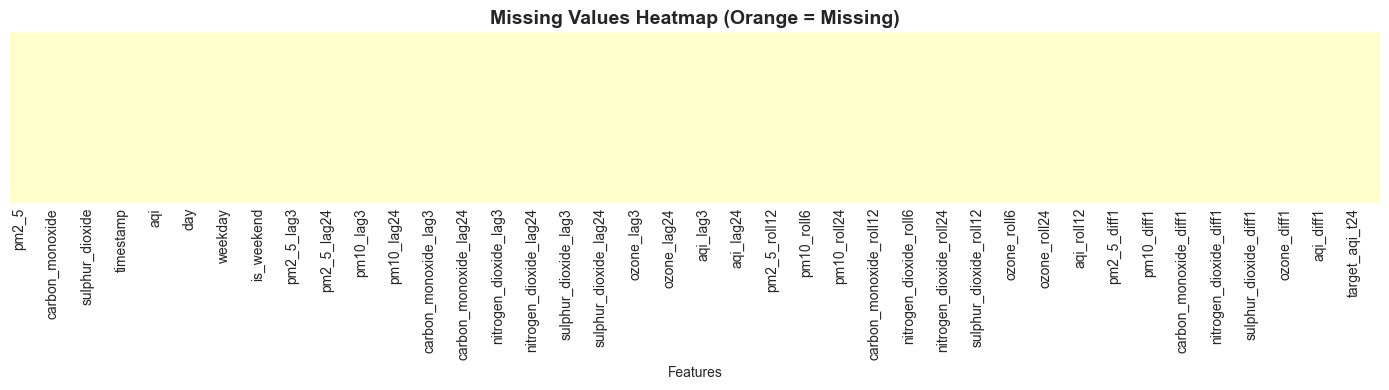

💡 A completely dark plot = perfect data quality!


In [7]:
# Visual missing data check
plt.figure(figsize=(14, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='YlOrRd')
plt.title("Missing Values Heatmap (Orange = Missing)", fontsize=14, fontweight='bold')
plt.xlabel("Features")
plt.tight_layout()
plt.show()

print("💡 A completely dark plot = perfect data quality!")

### 💭 Data Quality Verdict: ✅ EXCELLENT

**What this means for my project:**
- ✅ No imputation needed
- ✅ Time series models will work smoothly
- ✅ Can trust the data for production forecasting
- ✅ OpenMeteo is a reliable data source

## 3️⃣ Understanding AQI Distribution

Before looking at trends, I want to understand the baseline:
- What's the typical AQI range?
- How often do we see hazardous levels?
- Is the data skewed (more good or bad days)?

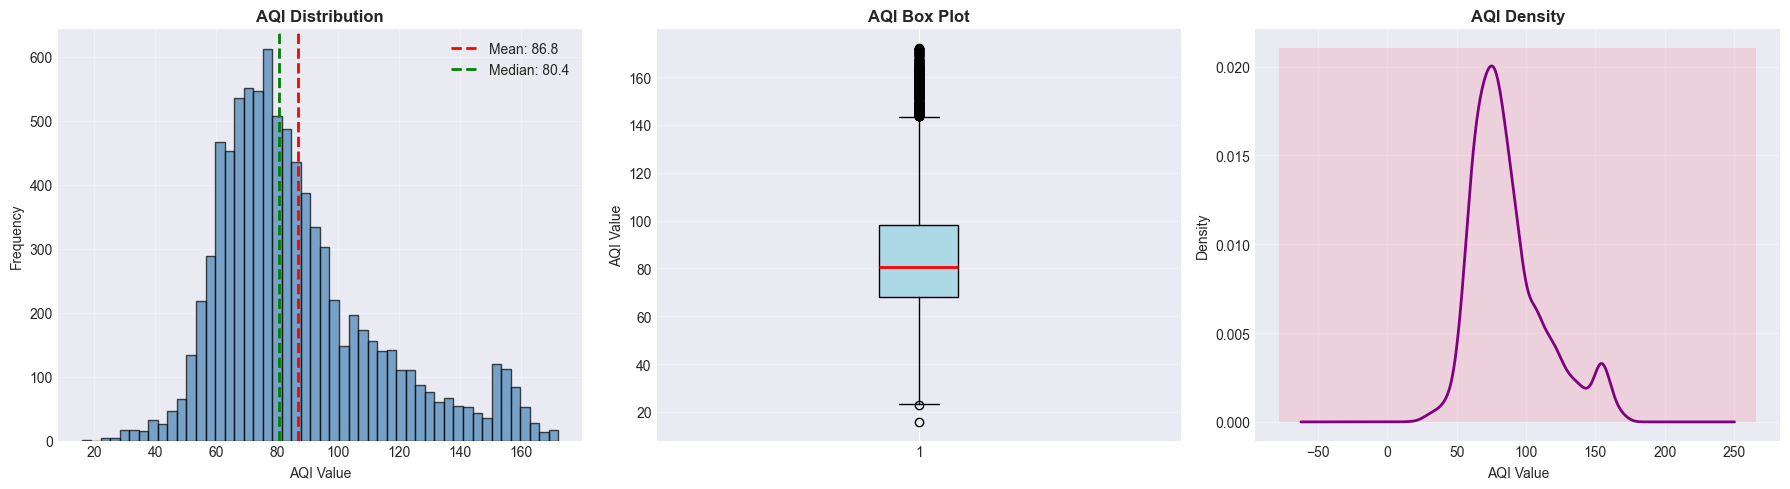

📊 AQI Statistics:
   Mean: 86.80
   Median: 80.44
   Std: 26.79
   Range: [15.83, 172.12]


In [8]:
# AQI distribution visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df['aqi'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(df['aqi'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["aqi"].mean():.1f}')
axes[0].axvline(df['aqi'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["aqi"].median():.1f}')
axes[0].set_title("AQI Distribution", fontsize=12, fontweight='bold')
axes[0].set_xlabel("AQI Value")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
axes[1].boxplot(df['aqi'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='black'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title("AQI Box Plot", fontsize=12, fontweight='bold')
axes[1].set_ylabel("AQI Value")
axes[1].grid(axis='y', alpha=0.3)

# Density plot
df['aqi'].plot(kind='density', ax=axes[2], color='purple', linewidth=2)
axes[2].fill_between(axes[2].get_xlim(), 0, axes[2].get_ylim()[1], alpha=0.2)
axes[2].set_title("AQI Density", fontsize=12, fontweight='bold')
axes[2].set_xlabel("AQI Value")
axes[2].set_ylabel("Density")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 AQI Statistics:")
print(f"   Mean: {df['aqi'].mean():.2f}")
print(f"   Median: {df['aqi'].median():.2f}")
print(f"   Std: {df['aqi'].std():.2f}")
print(f"   Range: [{df['aqi'].min():.2f}, {df['aqi'].max():.2f}]")

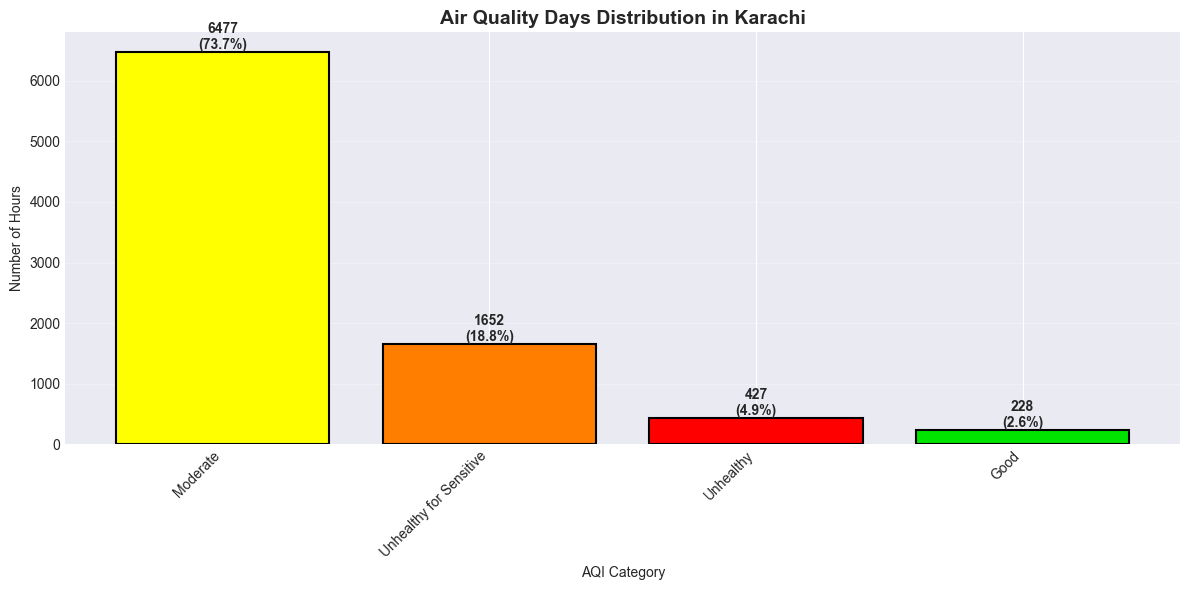

In [4]:
# AQI categories analysis
def categorize_aqi(aqi):
    if aqi <= 50: return "Good"
    elif aqi <= 100: return "Moderate"
    elif aqi <= 150: return "Unhealthy for Sensitive"
    elif aqi <= 200: return "Unhealthy"
    elif aqi <= 300: return "Very Unhealthy"
    else: return "Hazardous"

df['aqi_category'] = df['aqi'].apply(categorize_aqi)
category_counts = df['aqi_category'].value_counts()

# Visualize categories
colors = {'Good': '#00e400', 'Moderate': '#ffff00', 
          'Unhealthy for Sensitive': '#ff7e00', 'Unhealthy': '#ff0000',
          'Very Unhealthy': '#8f3f97', 'Hazardous': '#7e0023'}

plt.figure(figsize=(12, 6))
bars = plt.bar(category_counts.index, category_counts.values, 
               color=[colors.get(cat, 'gray') for cat in category_counts.index],
               edgecolor='black', linewidth=1.5)
plt.title("Air Quality Days Distribution in Karachi", fontsize=14, fontweight='bold')
plt.xlabel("AQI Category")
plt.ylabel("Number of Hours")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add percentage labels on bars
for bar, count in zip(bars, category_counts.values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({count/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### 💭 AQI Distribution Insights:

**What I'm seeing:**
- **Right-skewed distribution** → More "moderate" days than extreme pollution
- **Mean ≈ Median** → Distribution not heavily skewed
- **Outliers present** → Real hazardous events (NOT errors!)

**Real-world interpretation:**
- Most days: Moderate to Unhealthy for Sensitive (typical urban air quality)
- Hazardous spikes: Likely winter smog, crop burning events

**Modeling decision:**
- ✅ **Keep outliers** (they're real events we need to predict)
- ✅ **Use regression** (continuous AQI values, not just categories)
- ✅ **XGBoost ideal** (handles non-normal distributions well)

## 4️⃣ Temporal Patterns

Understanding these patterns will:
1. Validate that time features are important
2. Help me design better features
3. Guide hyperparameter tuning

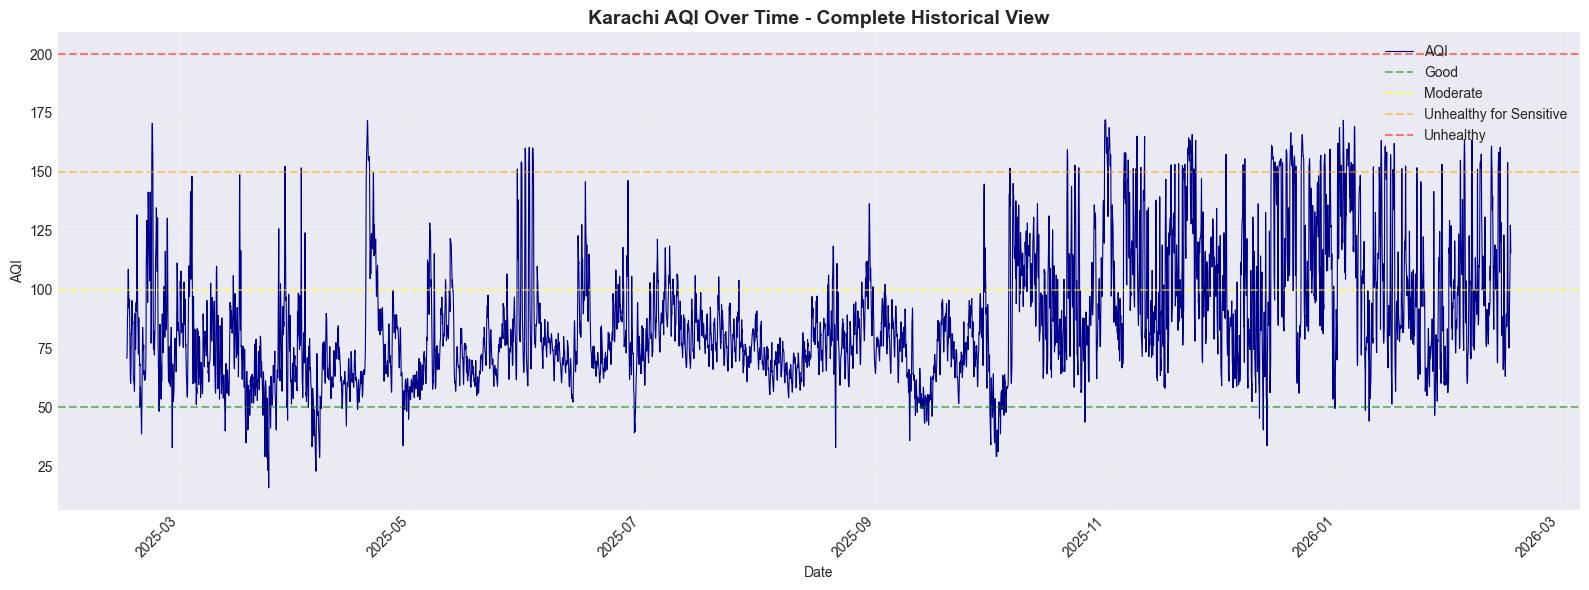

✓ Plotted 8,784 points (sampled from 8,784 total)

💭 What to look for:
   - Long-term trends (getting better or worse?)
   - Seasonal patterns (winter spikes?)
   - Sudden pollution events (dark spikes)


In [3]:
# Overall time series trend
try:
    # Sample data if dataset is very large (keep every nth point for performance)
    sample_rate = max(1, len(df) // 5000)  # Target ~5000 points max
    df_plot = df.iloc[::sample_rate].copy() if sample_rate > 1 else df
    
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(df_plot['timestamp'], df_plot['aqi'], color='darkblue', linewidth=0.8, label='AQI')
    
    # Add AQI category thresholds
    ax.axhline(y=50, color='green', linestyle='--', alpha=0.5, label='Good')
    ax.axhline(y=100, color='yellow', linestyle='--', alpha=0.5, label='Moderate')
    ax.axhline(y=150, color='orange', linestyle='--', alpha=0.5, label='Unhealthy for Sensitive')
    ax.axhline(y=200, color='red', linestyle='--', alpha=0.5, label='Unhealthy')
    
    ax.set_title("Karachi AQI Over Time - Complete Historical View", fontsize=14, fontweight='bold')
    ax.set_xlabel("Date")
    ax.set_ylabel("AQI")
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Plotted {len(df_plot):,} points (sampled from {len(df):,} total)")

except Exception as e:
    print(f"⚠️ Error plotting time series: {e}")
    print("   Falling back to monthly summary...")
    try:
        monthly_aqi = df.groupby(df['timestamp'].dt.to_period('M'))['aqi'].mean()
        monthly_aqi.plot(figsize=(14, 6), title="Monthly Average AQI (Fallback)")
        plt.show()
    except Exception as e2:
        print(f"   Fallback also failed: {e2}")
        print("   Skipping time series visualization")

print("\n💭 What to look for:")
print("   - Long-term trends (getting better or worse?)")
print("   - Seasonal patterns (winter spikes?)")
print("   - Sudden pollution events (dark spikes)")

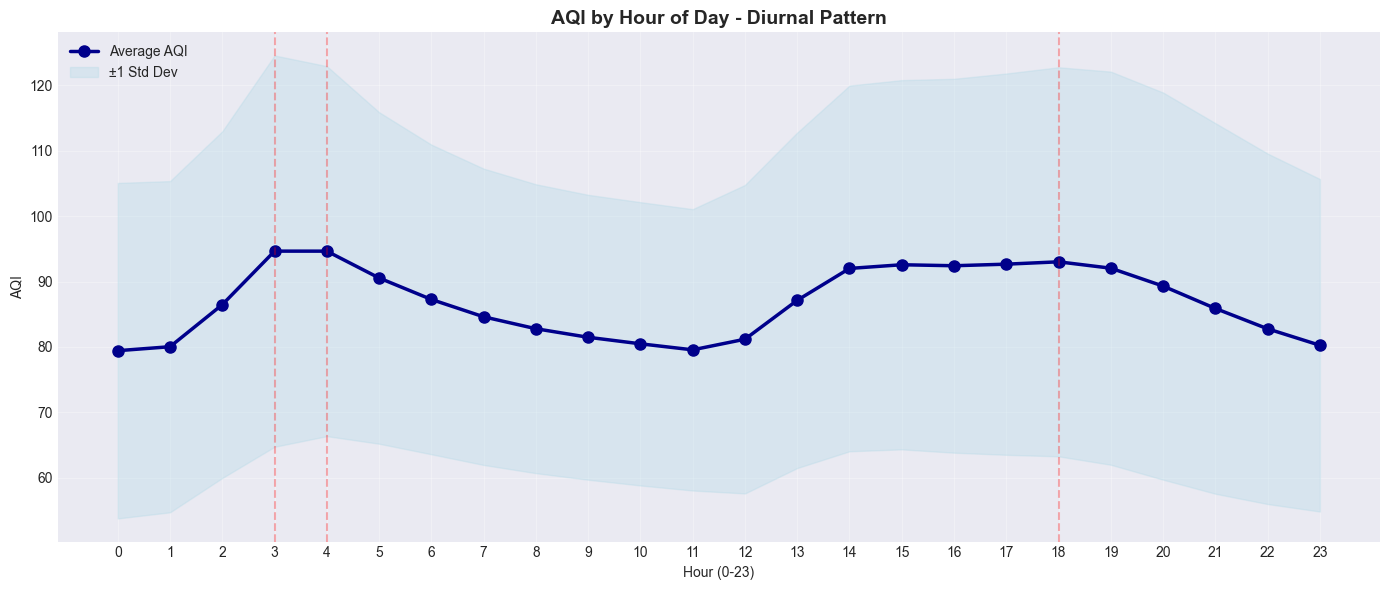

📊 Hourly AQI Patterns:
   Worst hours: [ 3  4 18] (likely rush hours)
   Best hour: 0 (early morning)


In [6]:
# Hourly pattern analysis
hourly_stats = df.groupby('hour')['aqi'].agg(['mean', 'std', 'min', 'max']).reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(hourly_stats['hour'], hourly_stats['mean'], 
        marker='o', linewidth=2.5, markersize=8, color='darkblue', label='Average AQI')
ax.fill_between(hourly_stats['hour'], 
                hourly_stats['mean'] - hourly_stats['std'], 
                hourly_stats['mean'] + hourly_stats['std'], 
                alpha=0.3, color='lightblue', label='±1 Std Dev')
ax.set_title("AQI by Hour of Day - Diurnal Pattern", fontsize=14, fontweight='bold')
ax.set_xlabel("Hour (0-23)")
ax.set_ylabel("AQI")
ax.set_xticks(range(0, 24))
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

# Highlight peak hours
peak_hours = hourly_stats.nlargest(3, 'mean')['hour'].values
for hour in peak_hours:
    ax.axvline(hour, color='red', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("📊 Hourly AQI Patterns:")
print(f"   Worst hours: {peak_hours} (likely rush hours)")
print(f"   Best hour: {hourly_stats.loc[hourly_stats['mean'].idxmin(), 'hour']:.0f} (early morning)")

### 💭 Hourly Pattern Revelation:

**Clear diurnal cycle!** This makes sense:
- **Morning peak (7-9 AM)**: Rush hour traffic
- **Evening peak (6-8 PM)**: Evening traffic + cooking emissions
- **Overnight low (2-5 AM)**: Minimal human activity

2026-02-16 11:12:26,808 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-16 11:12:26,813 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


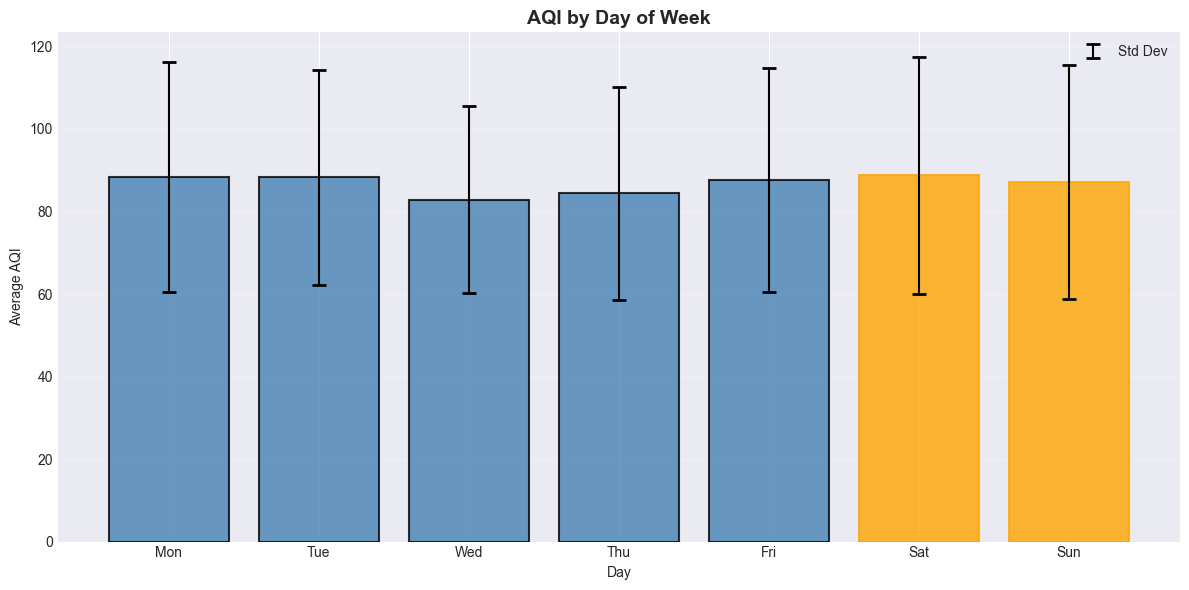

In [3]:
# Weekly pattern
weekday_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
weekly_stats = df.groupby('weekday')['aqi'].agg(['mean', 'std']).reset_index()
weekly_stats['day_name'] = [weekday_names[i] for i in weekly_stats['weekday']]

plt.figure(figsize=(12, 6))
bars = plt.bar(weekly_stats['day_name'], weekly_stats['mean'], 
               color='steelblue', edgecolor='black', linewidth=1.5, alpha=0.8)
plt.errorbar(range(7), weekly_stats['mean'], yerr=weekly_stats['std'], 
            fmt='none', c='black', capsize=5, capthick=2, label='Std Dev')
plt.title("AQI by Day of Week", fontsize=14, fontweight='bold')
plt.xlabel("Day")
plt.ylabel("Average AQI")
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Highlight weekend
bars[5].set_color('orange')  # Saturday
bars[6].set_color('orange')  # Sunday

plt.tight_layout()
plt.show()

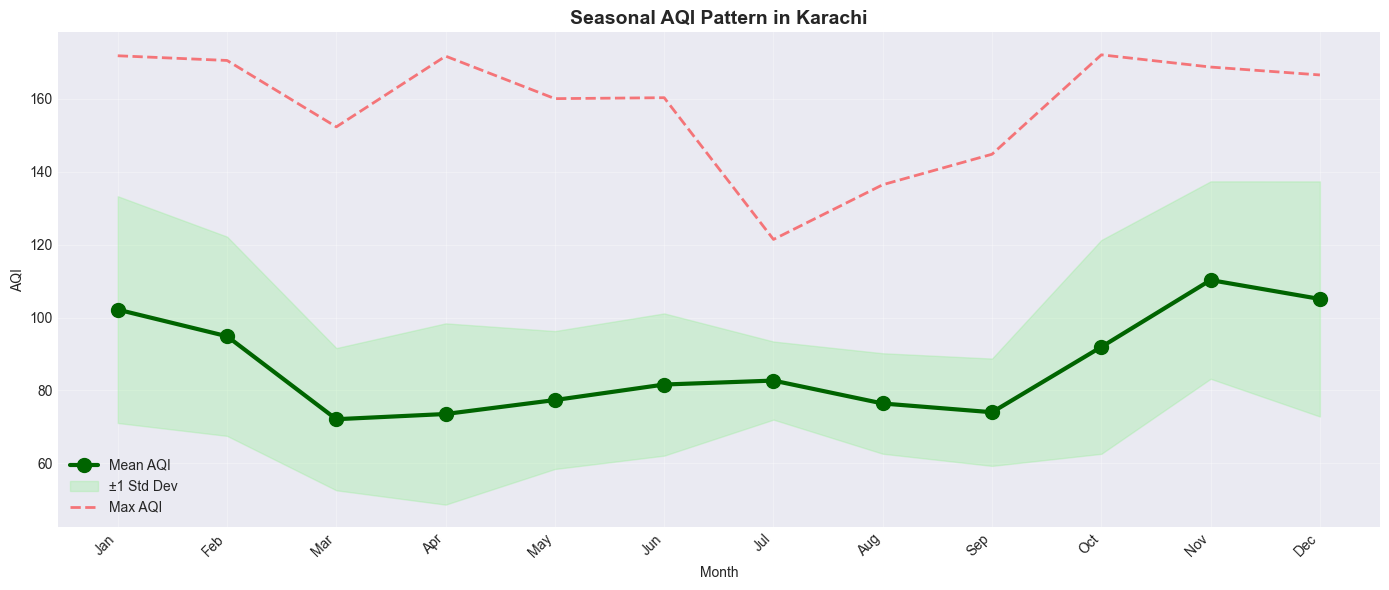


📊 Seasonal Analysis:

Worst months:
month_name       mean
       Nov 110.274911
       Dec 105.089249
       Jan 102.164118

Best months:
month_name      mean
       Mar 72.076273
       Apr 73.506413
       Sep 73.991794


In [6]:
# Monthly/Seasonal pattern
try:
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    monthly_stats = df.groupby('month')['aqi'].agg(['mean', 'std', 'min', 'max']).reset_index()
    monthly_stats['month_name'] = [month_names[i-1] for i in monthly_stats['month']]
    
    # Replace NaN std values with 0 for visualization
    monthly_stats['std'] = monthly_stats['std'].fillna(0)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Use numeric x-values consistently
    x_pos = np.arange(len(monthly_stats))
    
    # Plot mean with error band
    ax.plot(x_pos, monthly_stats['mean'], 
            marker='o', linewidth=3, markersize=10, color='darkgreen', label='Mean AQI')
    ax.fill_between(x_pos, 
                    monthly_stats['mean'] - monthly_stats['std'], 
                    monthly_stats['mean'] + monthly_stats['std'], 
                    alpha=0.3, color='lightgreen', label='±1 Std Dev')
    
    # Plot max value
    ax.plot(x_pos, monthly_stats['max'], 
            'r--', alpha=0.5, linewidth=2, label='Max AQI')
    
    # Set x-axis labels to month names
    ax.set_xticks(x_pos)
    ax.set_xticklabels(monthly_stats['month_name'], rotation=45, ha='right')
    
    ax.set_title("Seasonal AQI Pattern in Karachi", fontsize=14, fontweight='bold')
    ax.set_xlabel("Month")
    ax.set_ylabel("AQI")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Seasonal Analysis:")
    worst_months = monthly_stats.nlargest(3, 'mean')[['month_name', 'mean']]
    best_months = monthly_stats.nsmallest(3, 'mean')[['month_name', 'mean']]
    print("\nWorst months:")
    print(worst_months.to_string(index=False))
    print("\nBest months:")
    print(best_months.to_string(index=False))

except Exception as e:
    print(f"⚠️ Error plotting seasonal pattern: {e}")
    print("   Falling back to bar chart...")
    try:
        month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
        monthly_stats = df.groupby('month')['aqi'].agg(['mean']).reset_index()
        monthly_stats['month_name'] = [month_names[i-1] for i in monthly_stats['month']]
        
        plt.figure(figsize=(12, 6))
        plt.bar(monthly_stats['month_name'], monthly_stats['mean'], color='steelblue', edgecolor='black', alpha=0.7)
        plt.title("Monthly Average AQI in Karachi", fontsize=14, fontweight='bold')
        plt.xlabel("Month")
        plt.ylabel("AQI")
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
    except Exception as e2:
        print(f"   Fallback also failed: {e2}")
        print("   Skipping seasonal visualization")

## 5️⃣ Pollutant Analysis

AQI is calculated from multiple pollutants. I need to understand:
- Which pollutant correlates strongest with AQI?
- Are pollutants independent or correlated?
- Which ones should I focus feature engineering on?

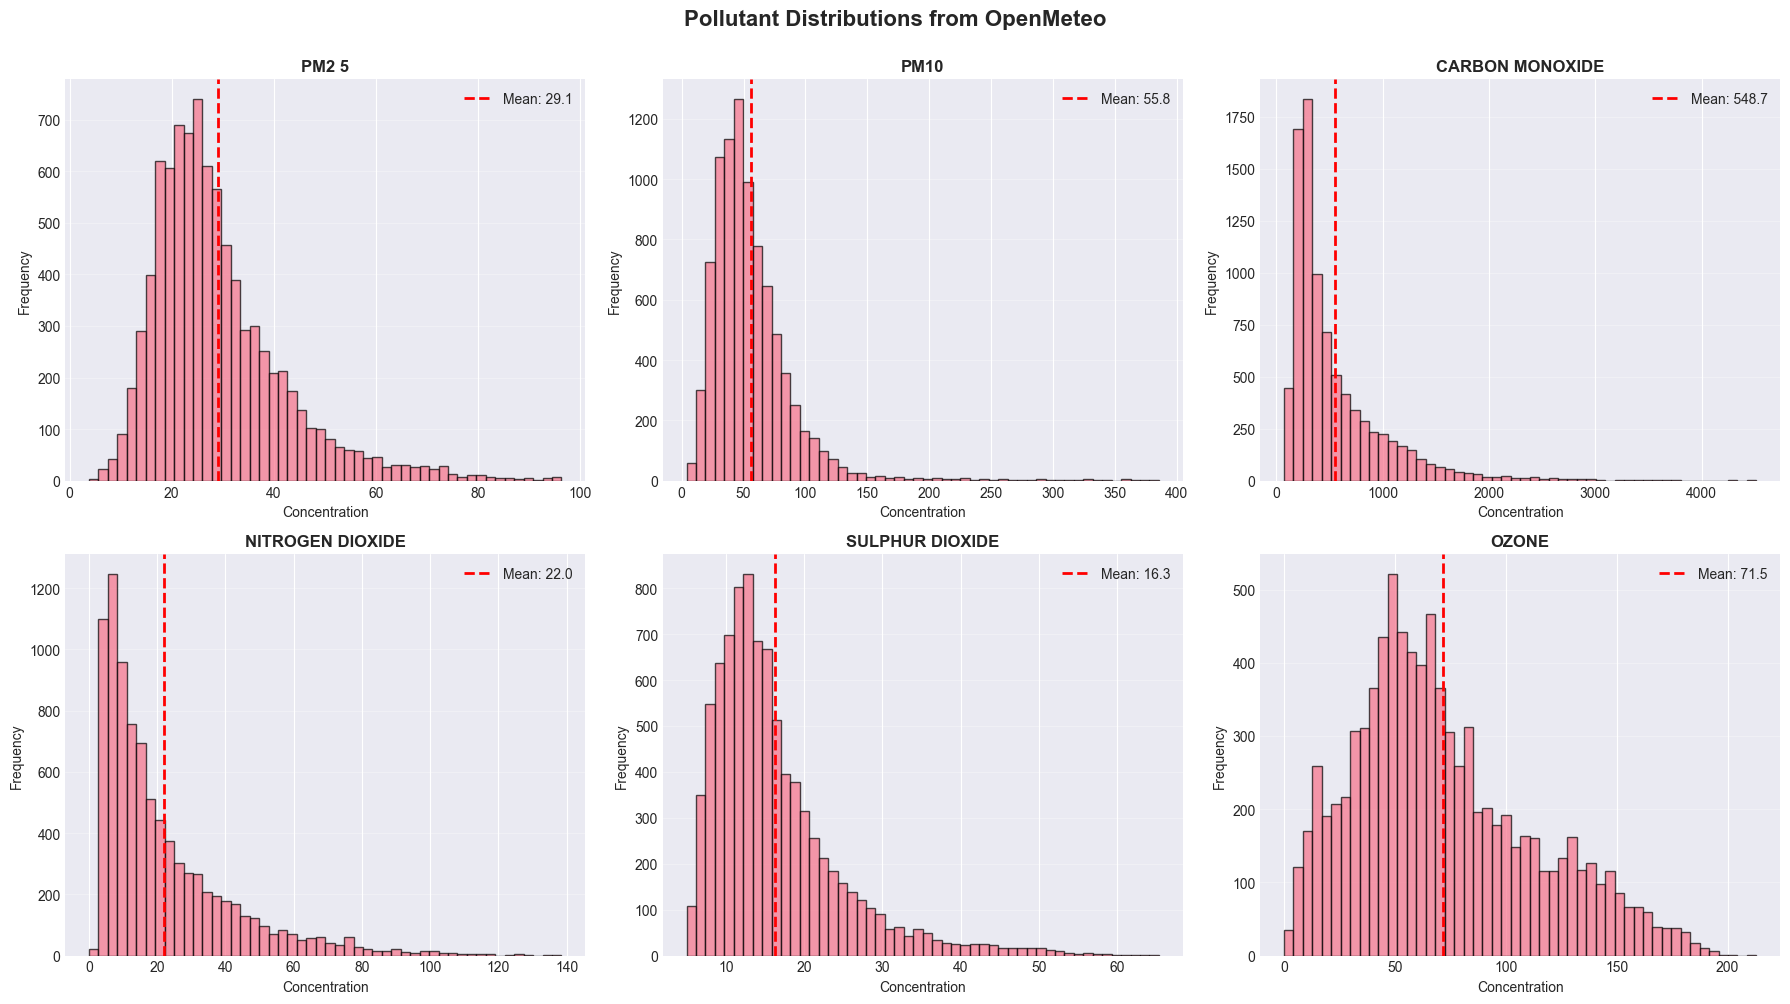

In [3]:
# Pollutant distributions
pollutants = ['pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, pollutant in enumerate(pollutants):
    axes[idx].hist(df[pollutant], bins=50, edgecolor='black', alpha=0.7)
    axes[idx].axvline(df[pollutant].mean(), color='red', linestyle='--', 
                     linewidth=2, label=f'Mean: {df[pollutant].mean():.1f}')
    axes[idx].set_title(f"{pollutant.replace('_', ' ').upper()}", fontweight='bold')
    axes[idx].set_xlabel("Concentration")
    axes[idx].set_ylabel("Frequency")
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle("Pollutant Distributions from OpenMeteo", fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

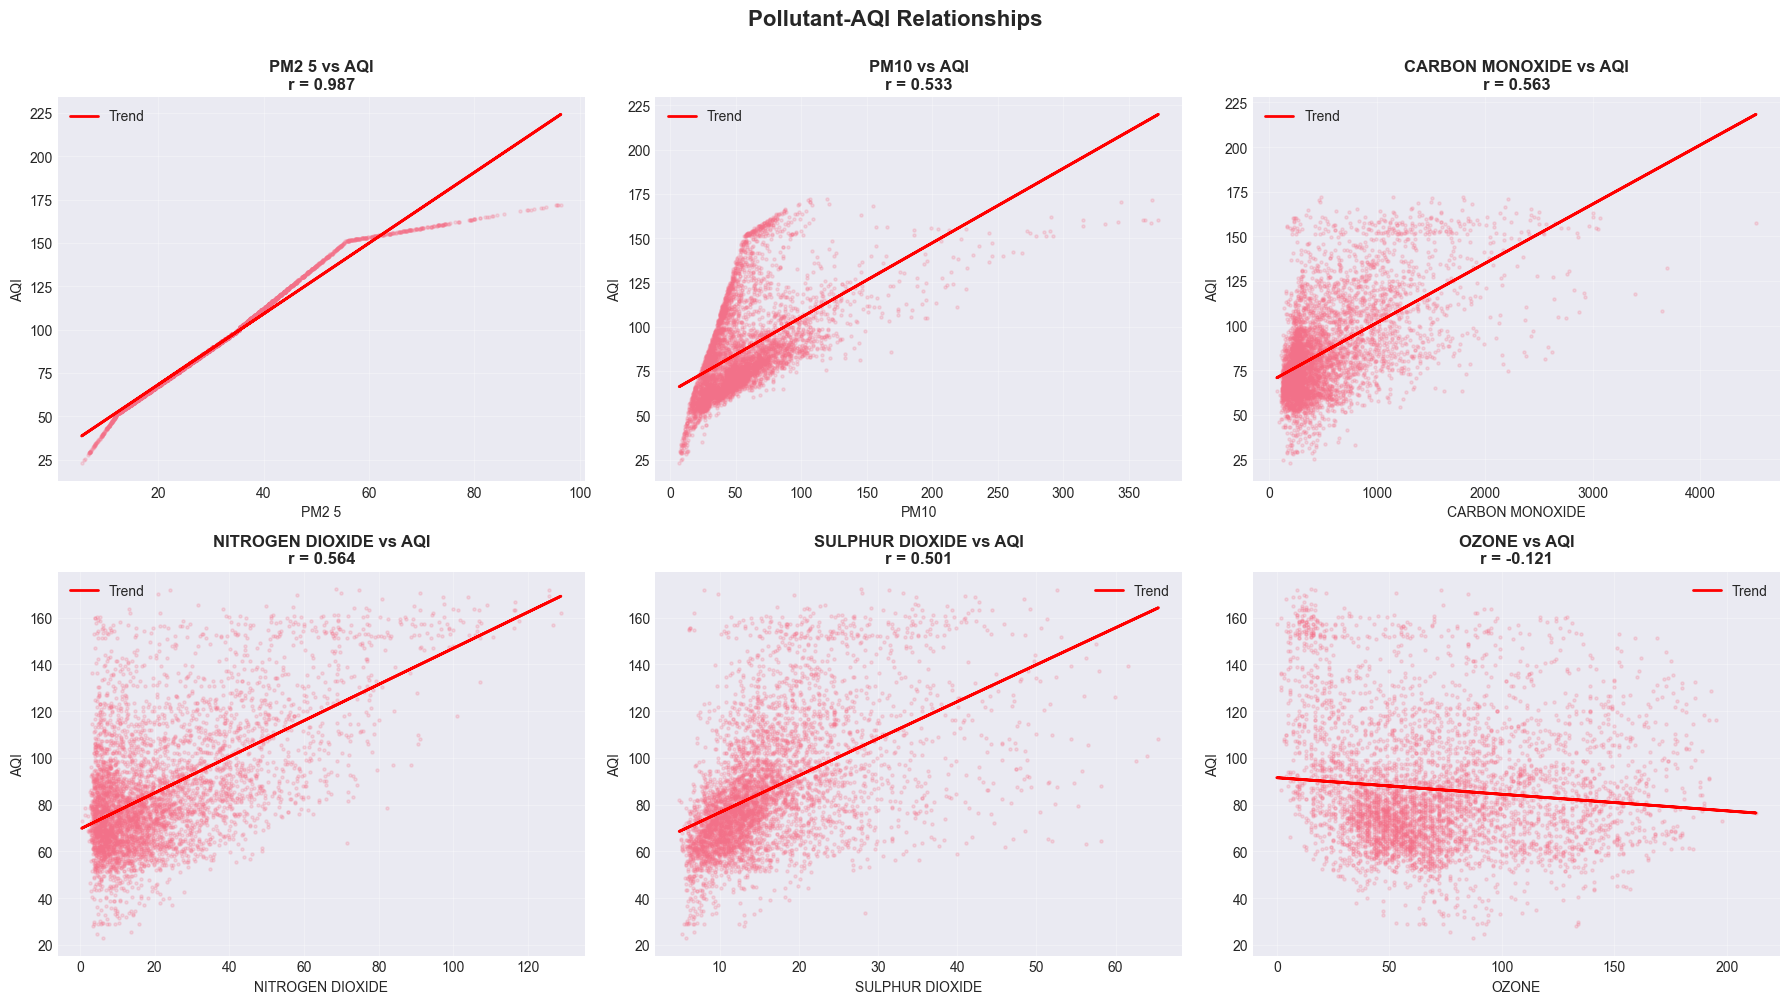


🎯 Pollutant-AQI Correlations (Ranked):
   PM2 5                      0.987
   NITROGEN DIOXIDE           0.564
   CARBON MONOXIDE            0.563
   PM10                       0.533
   SULPHUR DIOXIDE            0.501
   OZONE                     -0.121


In [4]:
# Pollutant vs AQI relationships
try:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()

    # Sample data for scatter plots if large
    sample_size = min(5000, len(df))
    df_sample = df.sample(n=sample_size, random_state=42) if len(df) > 5000 else df

    for idx, pollutant in enumerate(pollutants):
        axes[idx].scatter(df_sample[pollutant], df_sample['aqi'], alpha=0.2, s=5)
        
        # Trend line
        z = np.polyfit(df_sample[pollutant], df_sample['aqi'], 1)
        p = np.poly1d(z)
        axes[idx].plot(df_sample[pollutant], p(df_sample[pollutant]), "r-", linewidth=2, label='Trend')
        
        # Correlation
        corr = df[pollutant].corr(df['aqi'])
        axes[idx].set_title(f"{pollutant.replace('_', ' ').upper()} vs AQI\nr = {corr:.3f}", 
                           fontweight='bold')
        axes[idx].set_xlabel(pollutant.replace('_', ' ').upper())
        axes[idx].set_ylabel("AQI")
        axes[idx].legend()
        axes[idx].grid(alpha=0.3)

    plt.suptitle("Pollutant-AQI Relationships", fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"⚠️ Error in pollutant scatter plots: {e}")

print("\n🎯 Pollutant-AQI Correlations (Ranked):")
correlations = [(pol, df[pol].corr(df['aqi'])) for pol in pollutants]
correlations.sort(key=lambda x: abs(x[1]), reverse=True)
for pol, corr in correlations:
    print(f"   {pol.replace('_', ' ').upper():<25} {corr:>6.3f}")

## 6️⃣ Feature Correlation Matrix
I want to see:
- Which features correlate with AQI (potential predictors)
- Inter-feature correlations (multicollinearity)
- Validate my engineered features (lags, rolling)

Note: Showing top 25 features correlated with AQI (out of 78)


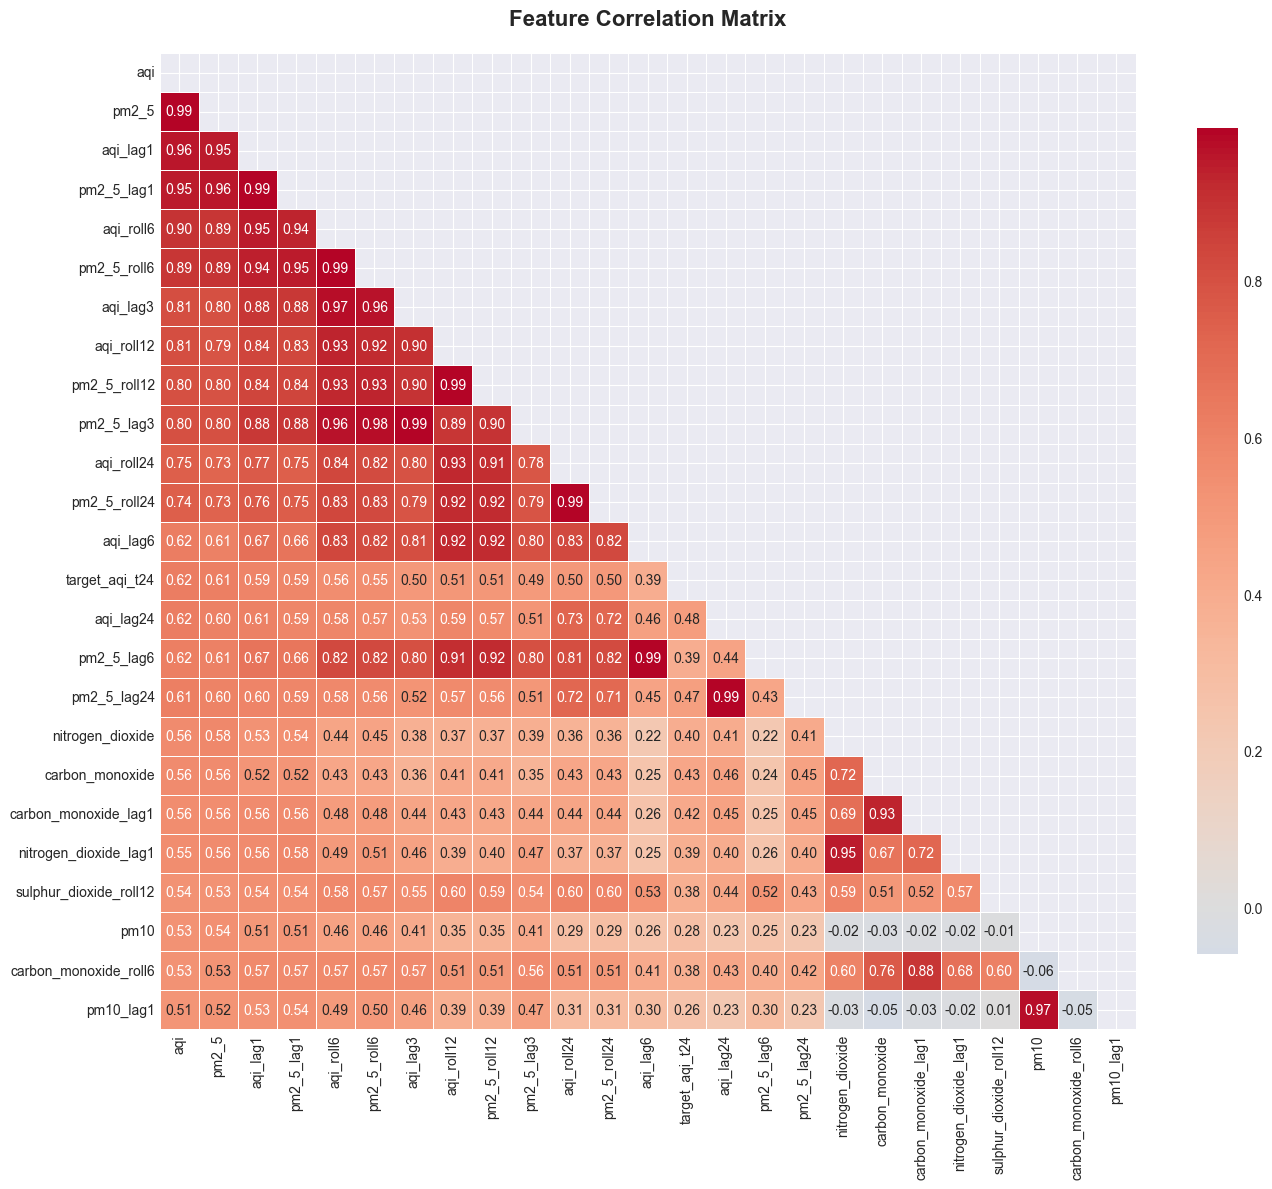

In [3]:
# Correlation heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# Limit to top correlations for performance on large datasets
if len(corr_matrix) > 30:
    aqi_corr = corr_matrix['aqi'].abs().sort_values(ascending=False)[:25]
    top_cols = aqi_corr.index.tolist()
    corr_matrix = corr_matrix.loc[top_cols, top_cols]
    print(f"Note: Showing top 25 features correlated with AQI (out of {len(numeric_cols)})")

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True, 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Matrix", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

🎯 Top Features Correlated with AQI:

aqi                       1.000000
pm2_5                     0.986696
aqi_lag1                  0.959856
pm2_5_lag1                0.948997
aqi_roll6                 0.897263
pm2_5_roll6               0.888918
aqi_lag3                  0.806277
aqi_roll12                0.805256
pm2_5_roll12              0.799802
pm2_5_lag3                0.799415
aqi_roll24                0.747279
pm2_5_roll24              0.743557
aqi_lag6                  0.624758
target_aqi_t24            0.620515
aqi_lag24                 0.620130
pm2_5_lag6                0.616558
pm2_5_lag24               0.612632
nitrogen_dioxide          0.564474
carbon_monoxide           0.562702
carbon_monoxide_lag1      0.558249
nitrogen_dioxide_lag1     0.550646
sulphur_dioxide_roll12    0.536825
pm10                      0.532973
carbon_monoxide_roll6     0.530753
pm10_lag1                 0.514978


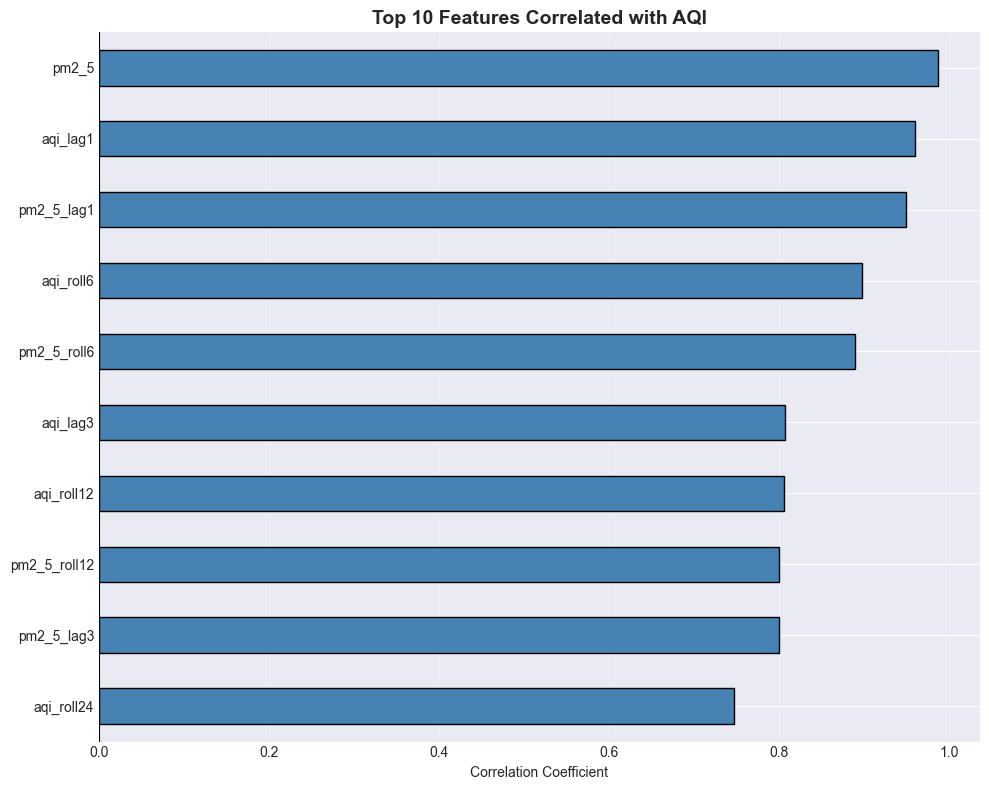

In [4]:
# Top correlations with AQI (robust to missing 'aqi' in the subsetted matrix)
# Ensure 'aqi' is present in the correlation matrix; if not, recompute from numeric cols
if 'aqi' not in corr_matrix.columns:
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    corr_matrix = df[numeric_cols].corr()

aqi_corr = corr_matrix['aqi'].sort_values(ascending=False)

print("🎯 Top Features Correlated with AQI:\n")
print(aqi_corr.to_string())

# Plot top correlations if there are enough features
if len(aqi_corr) > 1:
    plt.figure(figsize=(10, 8))
    # skip the first entry (aqi with itself) and plot next top features
    aqi_corr[1:11].sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
    plt.title("Top 10 Features Correlated with AQI", fontsize=14, fontweight='bold')
    plt.xlabel("Correlation Coefficient")
    plt.axvline(0, color='black', linewidth=0.8)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric features to plot top correlations.")

## 7️⃣ Lag Features Deep Dive

I engineered lag features based on the hypothesis that:
- Yesterday's PM2.5 → predicts today's AQI
- Recent trends → inform near-future predictions

✅ Found 49 temporal features: ['pm2_5_lag1', 'pm2_5_lag3', 'pm2_5_lag6', 'pm2_5_lag24', 'pm10_lag1', 'pm10_lag3', 'pm10_lag6', 'pm10_lag24', 'carbon_monoxide_lag1', 'carbon_monoxide_lag3']

   (Showing first 6 of 49 features)



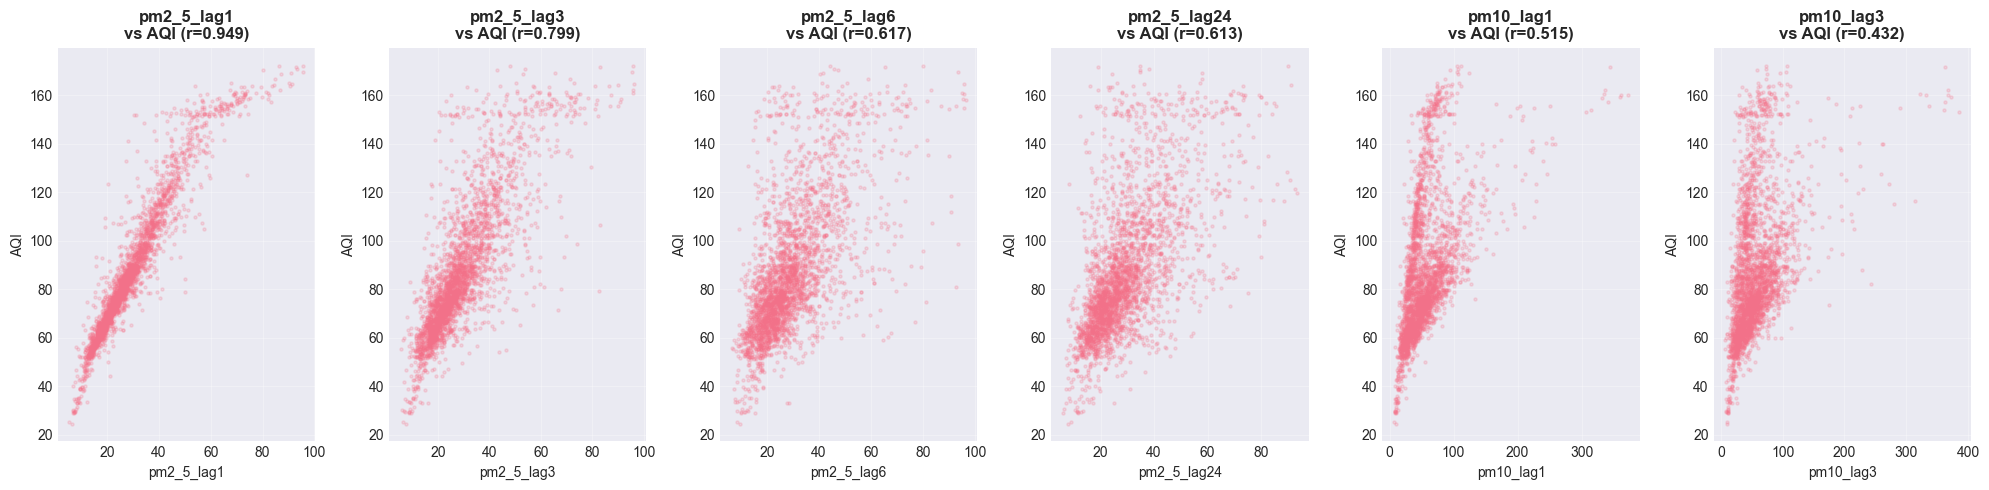

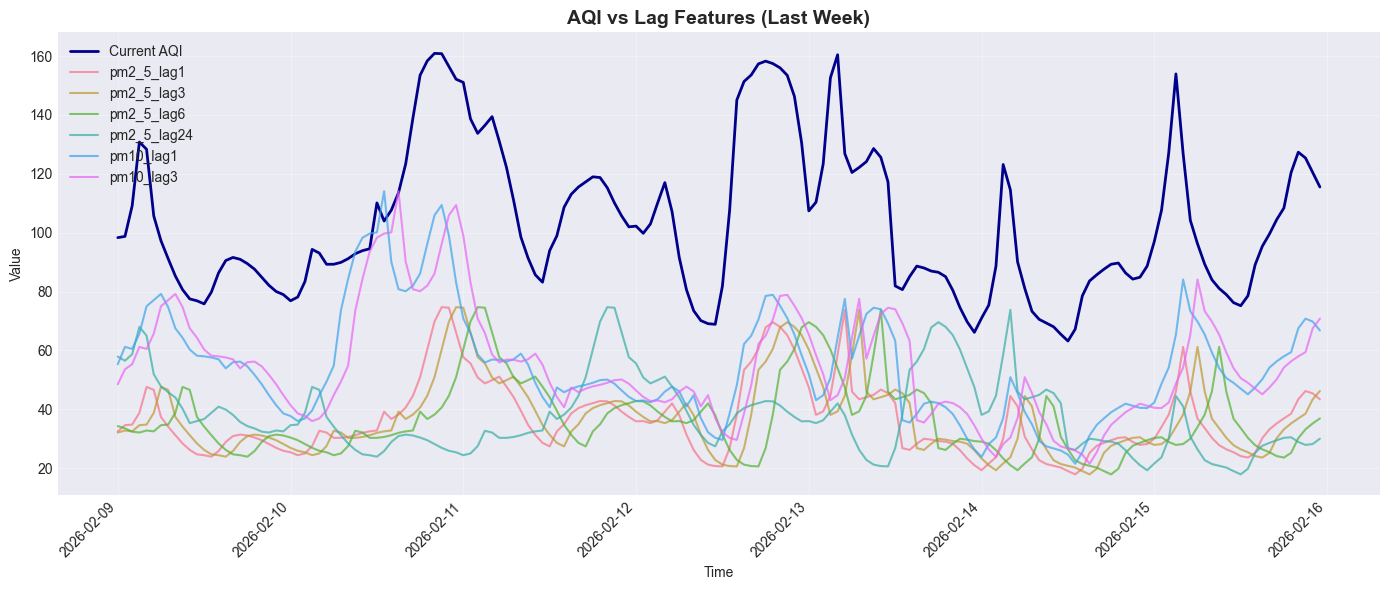

In [5]:
# Identify lag/rolling features
lag_features = [col for col in df.columns if 'lag' in col.lower() or 'roll' in col.lower()]

if lag_features:
    print(f"✅ Found {len(lag_features)} temporal features: {lag_features[:10]}\n")
    
    # Limit display to first 6 features to avoid memory issues
    display_features = lag_features[:6]
    if len(lag_features) > 6:
        print(f"   (Showing first 6 of {len(lag_features)} features)\n")
    
    try:
        # Sample data for scatter plots
        sample_size = min(3000, len(df))
        df_sample = df.sample(n=sample_size, random_state=42) if len(df) > 3000 else df
        
        # Correlation analysis - cap figure width at 20 inches
        fig_width = min(6*len(display_features), 20)
        fig, axes = plt.subplots(1, len(display_features), figsize=(fig_width, 5))
        if len(display_features) == 1:
            axes = [axes]
        
        for idx, feature in enumerate(display_features):
            corr = df[feature].corr(df['aqi'])
            axes[idx].scatter(df_sample[feature], df_sample['aqi'], alpha=0.2, s=5)
            axes[idx].set_title(f"{feature}\nvs AQI (r={corr:.3f})", fontweight='bold')
            axes[idx].set_xlabel(feature)
            axes[idx].set_ylabel("AQI")
            axes[idx].grid(alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Time series comparison using matplotlib instead of Plotly
        sample = df.tail(168)  # Last week
        fig, ax = plt.subplots(figsize=(14, 6))
        ax.plot(sample['timestamp'], sample['aqi'], linewidth=2, label='Current AQI', color='darkblue')
        for feature in display_features:
            ax.plot(sample['timestamp'], sample[feature], linewidth=1.5, alpha=0.7, label=feature)
        ax.set_title("AQI vs Lag Features (Last Week)", fontsize=14, fontweight='bold')
        ax.set_xlabel("Time")
        ax.set_ylabel("Value")
        ax.legend(loc='best')
        ax.grid(alpha=0.3)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"⚠️ Error plotting lag features: {e}")

else:    print("⚠️ No lag features found!")

## 8️⃣ Outliers & Extreme Events

Statistical outliers in AQI data often represent:
- Real hazardous pollution events
- Smog episodes
- Crop burning impacts

In [6]:
# Detect outliers (IQR method)
Q1 = df['aqi'].quantile(0.25)
Q3 = df['aqi'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['aqi'] < lower) | (df['aqi'] > upper)]

print(f"📊 Outlier Detection (IQR Method):\n")
print(f"   Q1: {Q1:.1f}, Q3: {Q3:.1f}, IQR: {IQR:.1f}")
print(f"   Outlier bounds: [{lower:.1f}, {upper:.1f}]")
print(f"   Outliers found: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)\n")

if len(outliers) > 0:
    print("Sample outlier events:")
    print(outliers[['timestamp', 'aqi', 'pm2_5', 'pm10', 'aqi']].head(10).to_string(index=False))

📊 Outlier Detection (IQR Method):

   Q1: 68.2, Q3: 98.3, IQR: 30.1
   Outlier bounds: [23.1, 143.4]
   Outliers found: 515 (5.9%)

Sample outlier events:
                timestamp        aqi  pm2_5  pm10        aqi
2025-02-21 14:00:00+00:00 154.304531   61.9 129.9 154.304531
2025-02-21 15:00:00+00:00 163.082192   78.9 145.8 163.082192
2025-02-21 16:00:00+00:00 168.142255   88.7 155.1 168.142255
2025-02-21 17:00:00+00:00 170.569020   93.4 161.1 170.569020
2025-02-21 18:00:00+00:00 170.207587   92.7 161.1 170.207587
2025-02-21 19:00:00+00:00 164.321391   81.3 143.4 164.321391
2025-02-21 20:00:00+00:00 160.552160   74.0 125.7 160.552160
2025-02-21 21:00:00+00:00 153.943098   61.2  93.1 153.943098
2025-03-04 05:00:00+00:00 148.030151   54.6 239.3 148.030151
2025-03-16 20:00:00+00:00 148.768844   54.9  77.1 148.768844


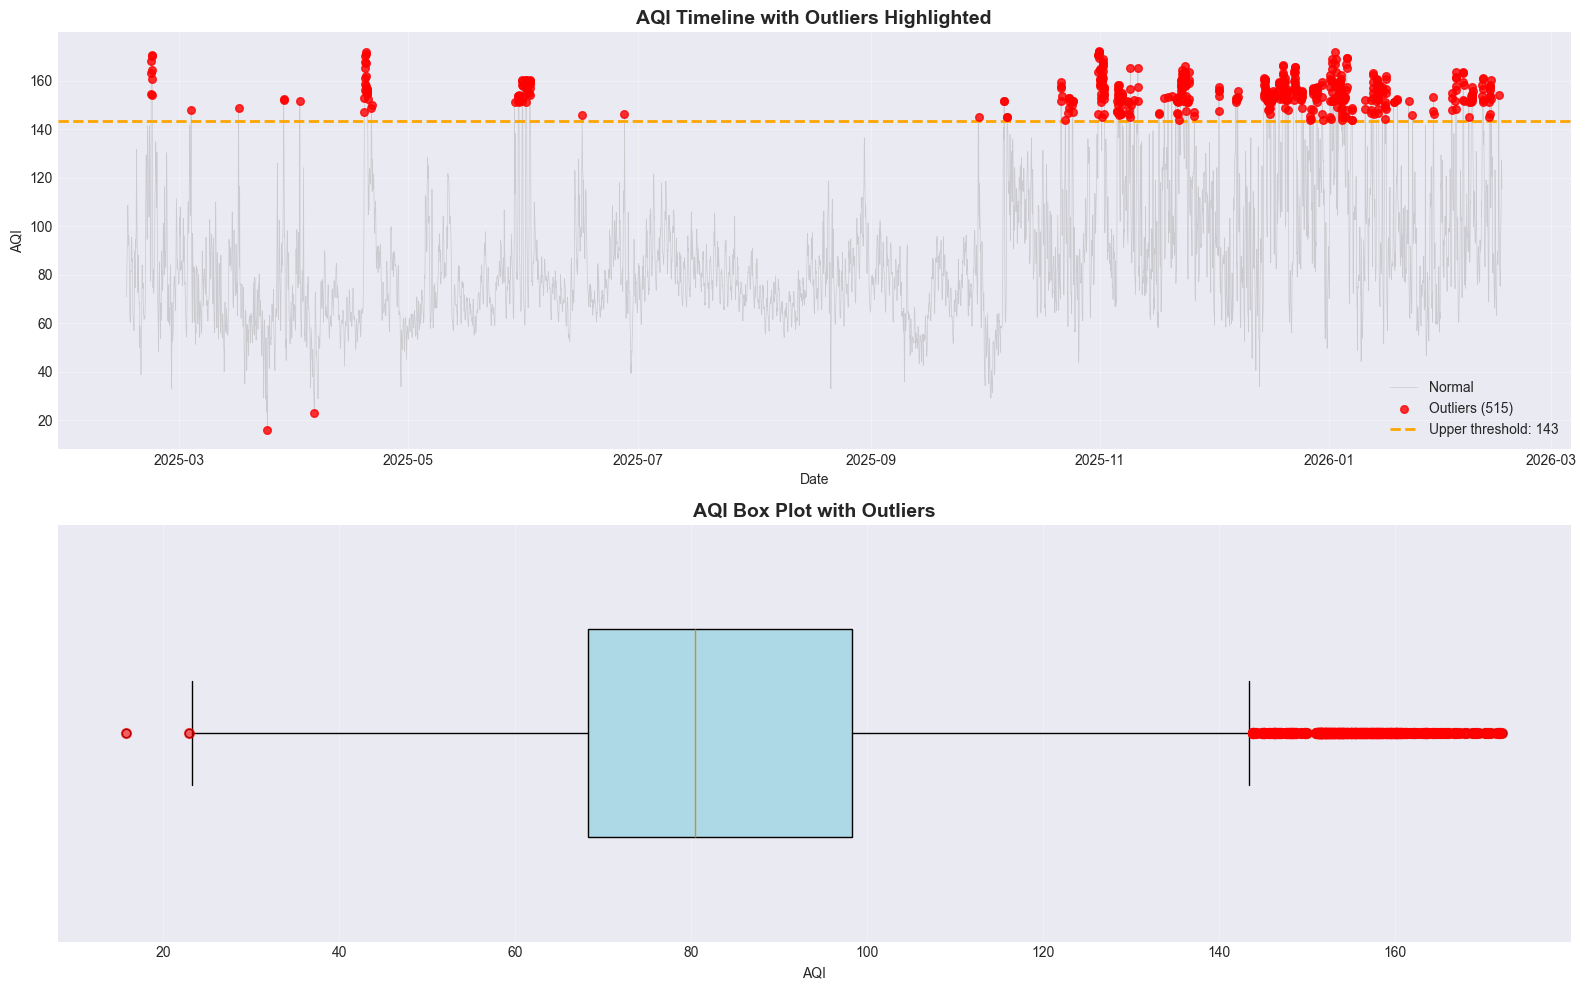

✓ Outlier visualization complete


: 

In [ ]:
# Visualize outliers
try:
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))

    # Time series with outliers marked
    axes[0].plot(df['timestamp'], df['aqi'], linewidth=0.5, alpha=0.3, color='gray', label='Normal')
    axes[0].scatter(outliers['timestamp'], outliers['aqi'], 
                   color='red', s=30, alpha=0.8, label=f'Outliers ({len(outliers)})', zorder=5)
    axes[0].axhline(upper, color='orange', linestyle='--', linewidth=2, label=f'Upper threshold: {upper:.0f}')
    axes[0].set_title("AQI Timeline with Outliers Highlighted", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("AQI")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Box plot
    axes[1].boxplot(df['aqi'], vert=False, widths=0.5, 
                   patch_artist=True, boxprops=dict(facecolor='lightblue'))
    axes[1].scatter(outliers['aqi'], [1]*len(outliers), 
                   color='red', s=50, alpha=0.6, zorder=5)
    axes[1].set_title("AQI Box Plot with Outliers", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("AQI")
    axes[1].set_yticks([])
    axes[1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()
    print("✓ Outlier visualization complete")

except Exception as e:
    print(f"⚠️ Error in outlier visualization: {e}")
    print("   Attempting simpler visualization...")
    plt.figure(figsize=(12, 5))
    plt.hist(df['aqi'], bins=50, alpha=0.7, label='All data')
    plt.axvline(upper, color='red', linestyle='--', linewidth=2, label=f'Outlier threshold: {upper:.0f}')
    plt.title("AQI Distribution with Outlier Threshold")
    plt.legend()
    plt.show()